In [ ]:
He hecho el ejercicio sin preparacion previa mas que de github y leerme por arriba tus ejemplos.
Me he pasado todo el tiempo entendiendo a como se ejecuta el notebook y no he hecho las conclusiones.
He usado la IA para adaptar la mayoria de tus ejemplos al ejercicio. 
No hay que corregir y mas necesitando un 5 para aprobar.


In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [14]:
df = pd.read_csv(r"C:\Users\cesar\OneDrive - ESIC, Business & Marketing School\Clases 4º año\EDA_Prediccion\data\framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [16]:
#me ha ayudado 
print("\n--- Valores únicos por columna ---")
for col in df.columns:
    print(f"  {col:<20} {df[col].nunique():>4} únicos")


--- Valores únicos por columna ---
  male                    2 únicos
  age                    39 únicos
  education               4 únicos
  currentSmoker           2 únicos
  cigsPerDay             33 únicos
  BPMeds                  2 únicos
  prevalentStroke         2 únicos
  prevalentHyp            2 únicos
  diabetes                2 únicos
  totChol               248 únicos
  sysBP                 234 únicos
  diaBP                 146 únicos
  BMI                  1364 únicos
  heartRate              73 únicos
  glucose               143 únicos
  TenYearCHD              2 únicos


In [19]:
categorical_features = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
numeric_features     = ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
df[numeric_features].describe()
df[categorical_features].value_counts()

male  currentSmoker  BPMeds  prevalentStroke  prevalentHyp  diabetes
0     0              0.0     0                0             0           881
1     1              0.0     0                0             0           757
0     1              0.0     0                0             0           748
1     0              0.0     0                0             0           450
0     0              0.0     0                1             0           429
1     1              0.0     0                1             0           301
      0              0.0     0                1             0           204
0     1              0.0     0                1             0           179
      0              1.0     0                1             0            50
      1              1.0     0                1             0            26
      0              0.0     0                1             1            20
1     0              0.0     0                0             1            18
                   

In [22]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [ ]:
df['glucose']    = df['glucose'].fillna(df['glucose'].median())
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
df['totChol']    = df['totChol'].fillna(df['totChol'].median())
df['BMI']        = df['BMI'].fillna(df['BMI'].median())
df['heartRate']  = df['heartRate'].fillna(df['heartRate'].median())
df['BPMeds']     = df['BPMeds'].fillna(df['BPMeds'].mode()[0])
df['education']  = df['education'].fillna(df['education'].mode()[0])

print(df.isnull().sum()[df.isnull().sum() > 0])
print("Sin nulos" if df.isnull().sum().sum() == 0 else "")
#esto ultimo me lo escribe la ia



Series([], dtype: int64)
Sin nulos


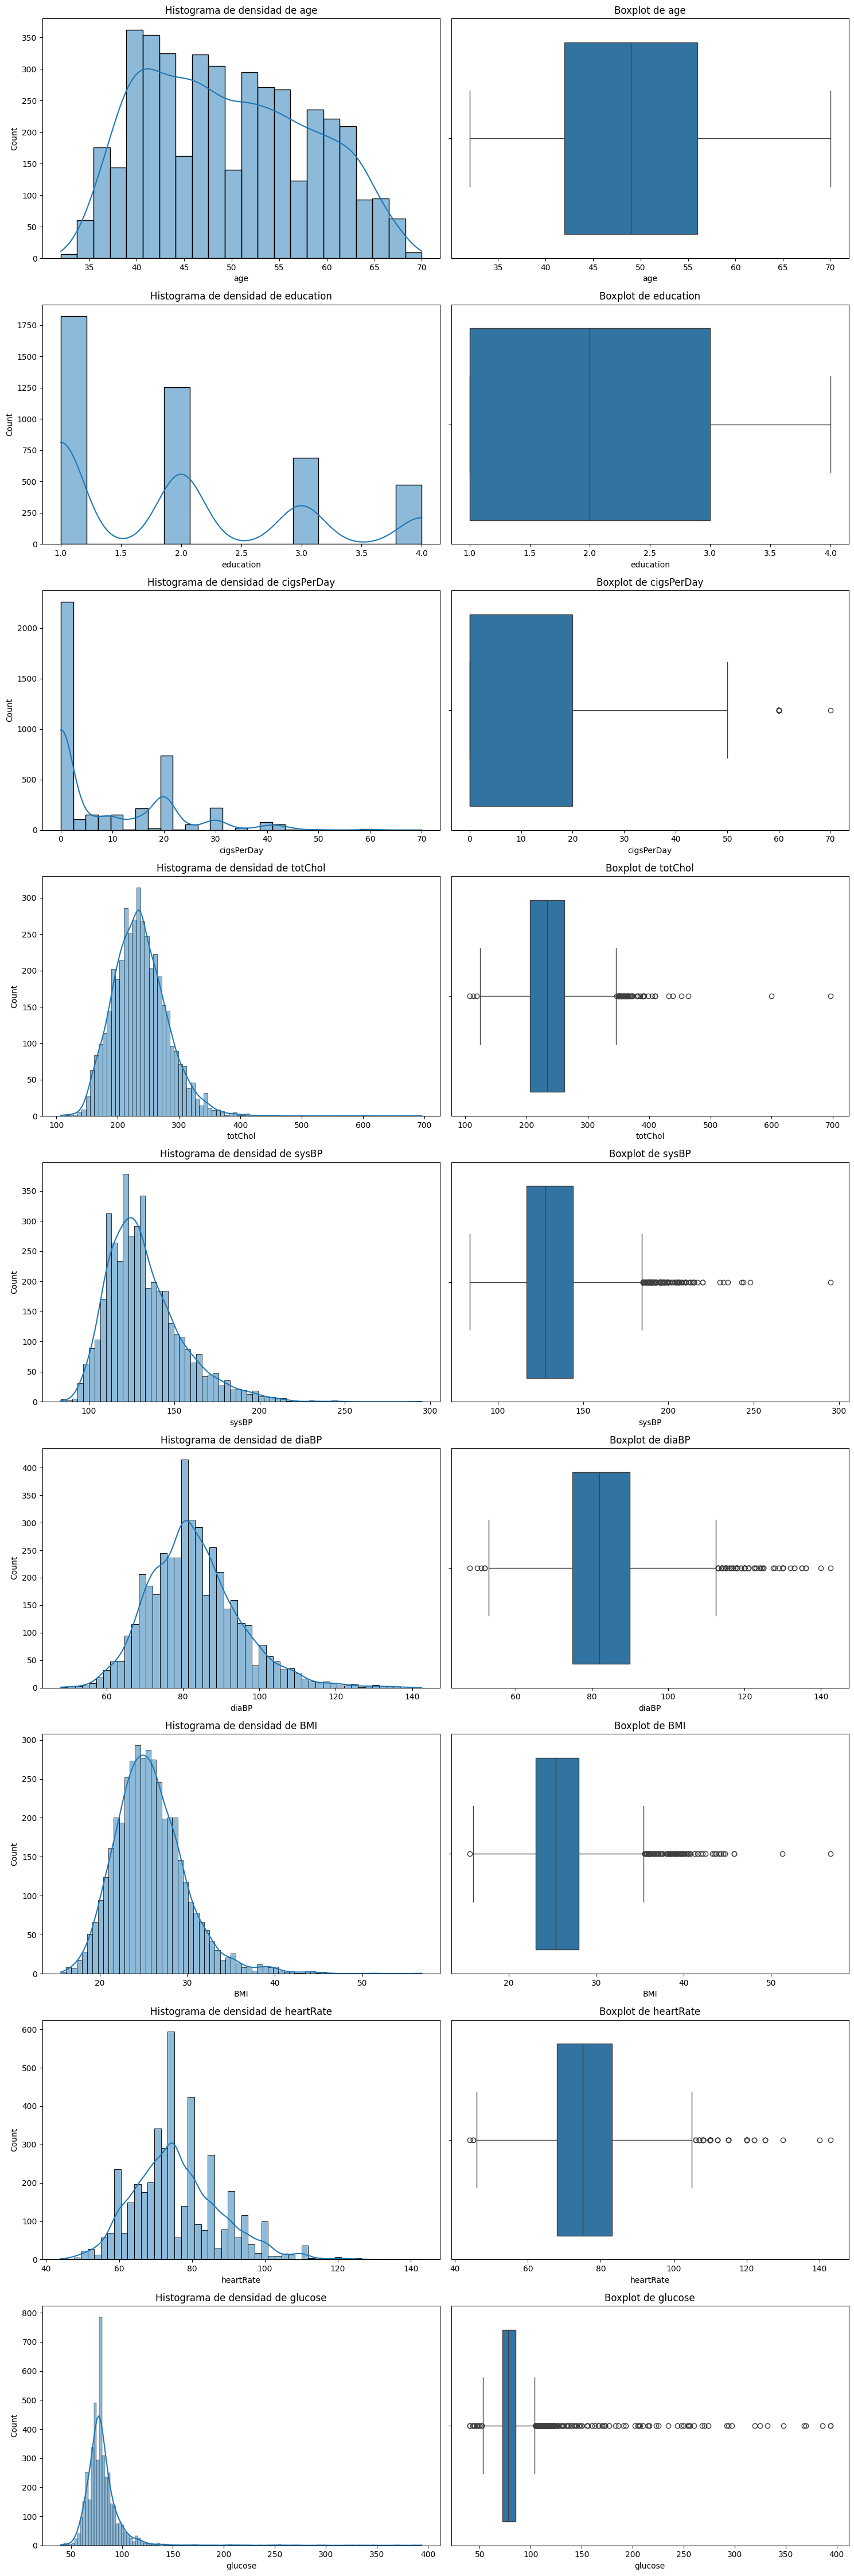

In [31]:

fig, axes = plt.subplots(nrows=len(numeric_features), ncols=2, 
                         figsize=(15, 5 * len(numeric_features)),
                         squeeze=False)
#fig axes adaptado con la IA de tus apuntes
for i, column in enumerate(numeric_features):
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

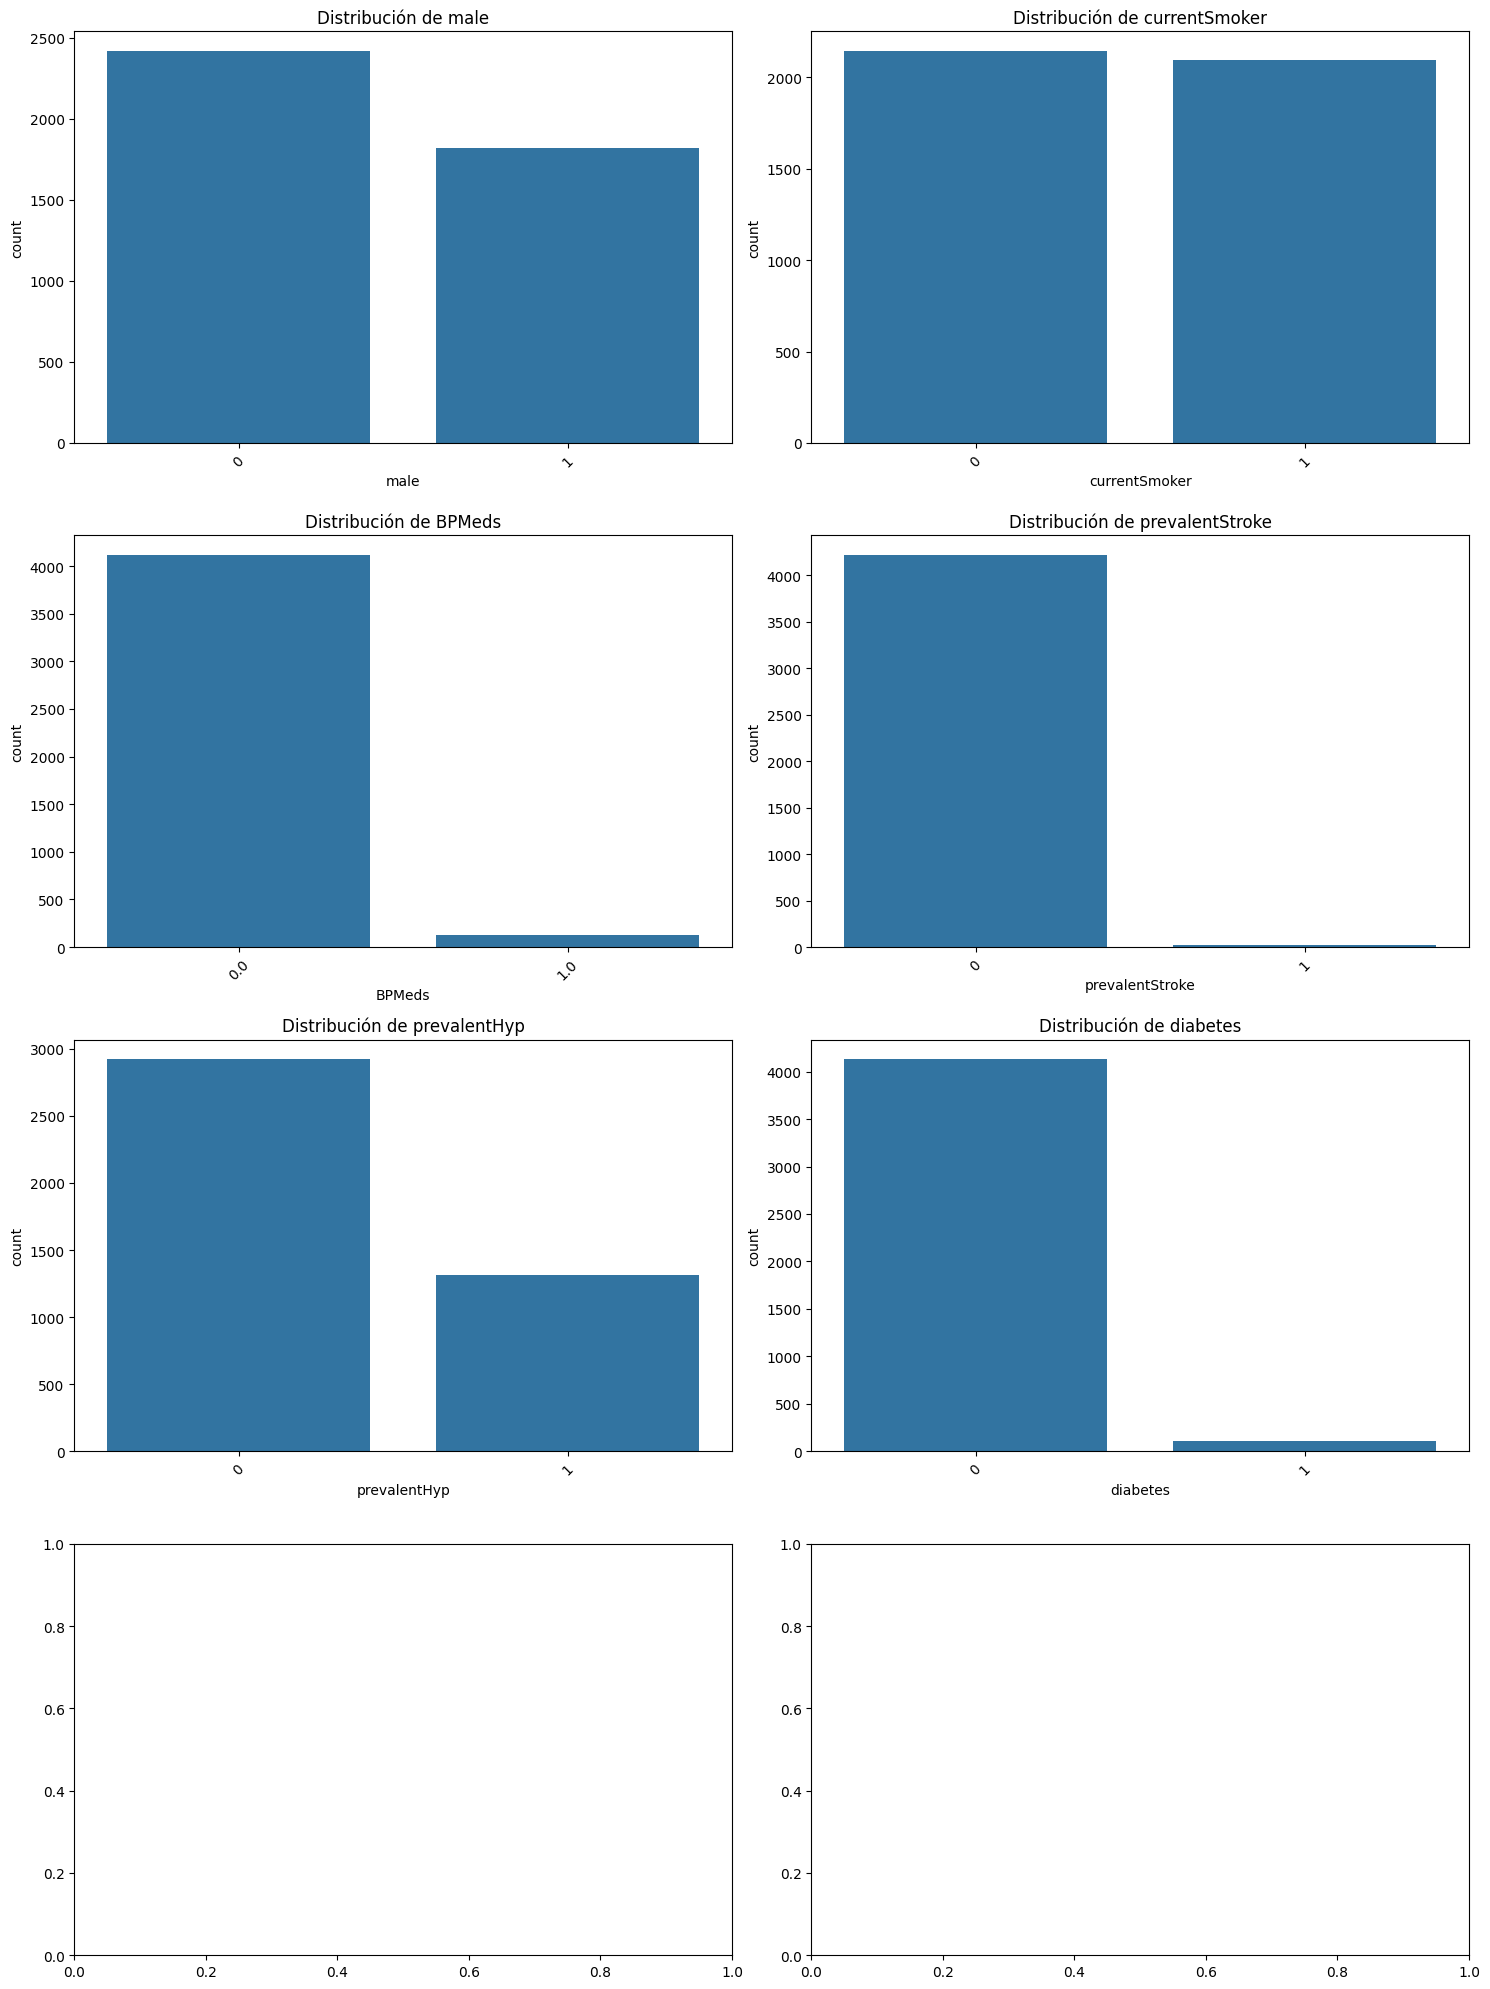

In [32]:
fig, axs = plt.subplots(nrows=len(categorical_features)//2 + 1, ncols=2, 
                        figsize=(15, 5 * (len(categorical_features)//2 + 1)),
                        squeeze=False)
axs = axs.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

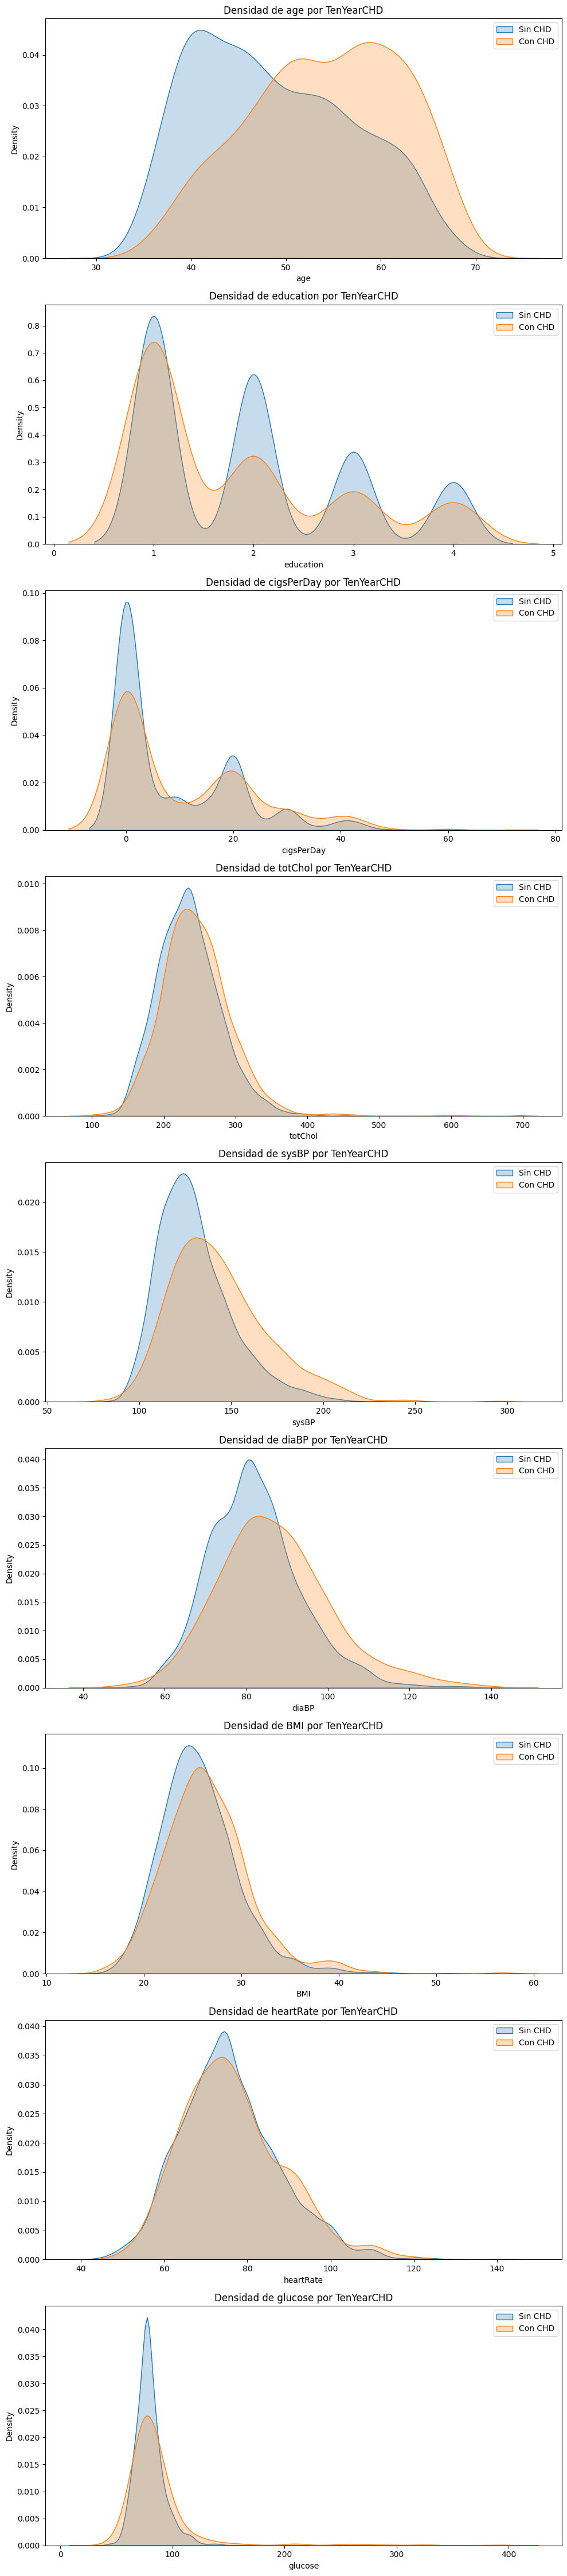

In [ ]:
#IA me ayuda en cuanto a target
target = 'TenYearCHD'


fig, axs = plt.subplots(nrows=len(numeric_features), ncols=1, 
                        figsize=(10, 5 * len(numeric_features)))

for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df[df[target] == 0], x=col, ax=axs[i], label='Sin CHD', fill=True)
    sns.kdeplot(data=df[df[target] == 1], x=col, ax=axs[i], label='Con CHD', fill=True)
    axs[i].set_title(f'Densidad de {col} por {target}')
    axs[i].legend()

plt.tight_layout()
plt.show()

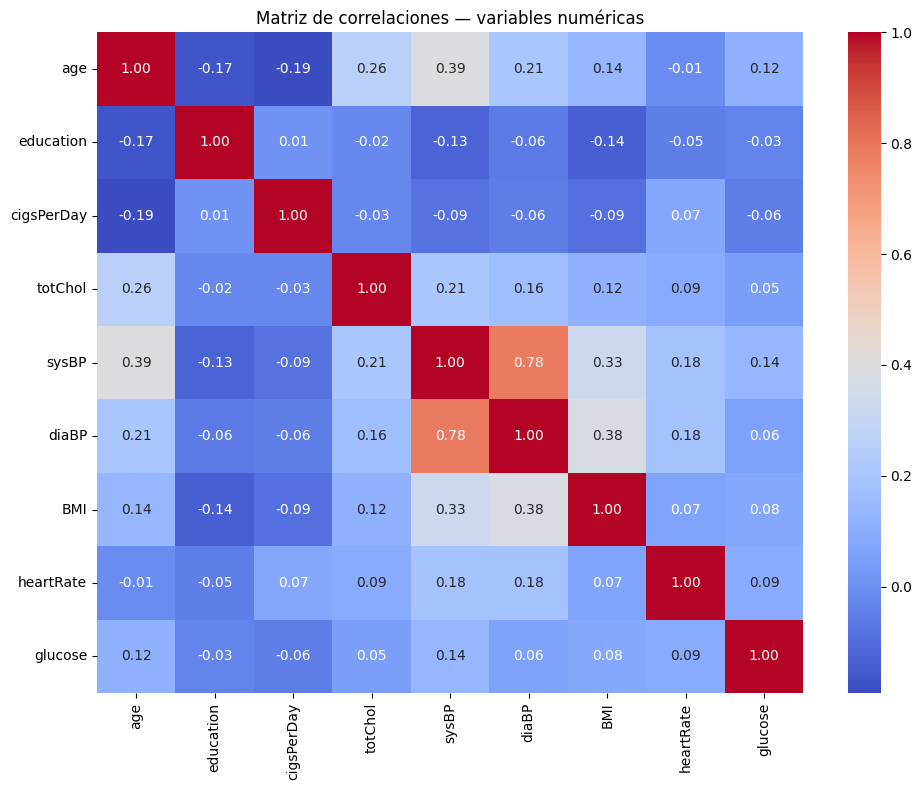

In [34]:
corr = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlaciones — variables numéricas')
plt.tight_layout()
plt.show()

In [ ]:
numeric_con_target = numeric_features + ['TenYearCHD']

corr_target = df[numeric_con_target].corr()['TenYearCHD'].sort_values(ascending=False)
print(corr_target)